# The seven retrieval configurations, read question by question

Reads `reports/ablation_results.json` and `reports/paired_comparison.json`, both
written by scripts and both committed. Nothing here calls a model: the run happened
on 2026-09-15 and this notebook reads what it left.

The question here: on twenty questions, which of the seven can be told apart at all.

In [1]:
import json

from events_rag.utils.paths import REPORTS_DIR

ablation = json.loads((REPORTS_DIR / 'ablation_results.json').read_text(encoding='utf-8'))
paired = json.loads((REPORTS_DIR / 'paired_comparison.json').read_text(encoding='utf-8'))
results = {row['name']: row for row in ablation['results']}
list(results)

['bm25-only',
 'dense-baseline',
 'dense-one-chunk-per-event',
 'dense-metadata-header',
 'dense+city-filter',
 'hybrid-rrf',
 'hybrid-rrf+rerank']

## The averages, and what they hide

`recall@k` is the share of questions whose source event appears in the first k
results. Read across k, the curve says how far down the list you have to look.

In [2]:
ks = (1, 3, 5, 10)
print(f"{'configuration':30}" + ''.join(f'recall@{k:<5}' for k in ks) + 'MRR@10')
for name, row in results.items():
    metrics = row['metrics']
    line = ''.join(f"{metrics[f'recall@{k}']:<13.2f}" for k in ks)
    print(f'{name:30}{line}{metrics["mrr@10"]:.3f}')

configuration                 recall@1    recall@3    recall@5    recall@10   MRR@10
bm25-only                     0.50         0.70         0.75         0.90         0.615
dense-baseline                0.90         1.00         1.00         1.00         0.950
dense-one-chunk-per-event     0.85         0.95         0.95         1.00         0.900
dense-metadata-header         0.80         0.85         0.95         1.00         0.855
dense+city-filter             0.95         1.00         1.00         1.00         0.975
hybrid-rrf                    0.80         0.90         0.95         1.00         0.857
hybrid-rrf+rerank             0.65         0.85         0.85         0.90         0.750


The ablation has two axes, and they are read separately. The five **search**
strategies below all index the corpus the same way and differ in how they search it;
the two **chunking** variants differ in how the corpus is cut, and sit in the table
above. Five series is what the shared palette carries without reusing a hue.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


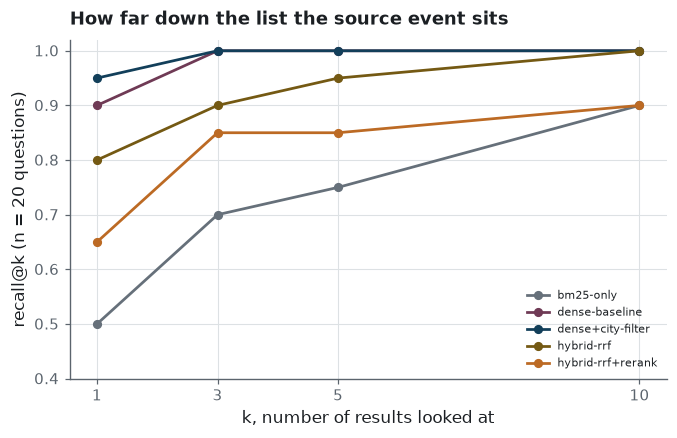

In [3]:
import matplotlib.pyplot as plt

from events_rag.figure_style import apply_style, series_colours

apply_style()
search = ['bm25-only', 'dense-baseline', 'dense+city-filter', 'hybrid-rrf', 'hybrid-rrf+rerank']
colours = series_colours(search, control=['bm25-only'])
fig, ax = plt.subplots(figsize=(7, 4))
for name in search:
    ax.plot(
        ks,
        [results[name]['metrics'][f'recall@{k}'] for k in ks],
        marker='o', label=name, color=colours[name],
    )
ax.set_xticks(ks)
ax.set_xlabel('k, number of results looked at')
ax.set_ylabel(f"recall@k (n = {ablation['results'][0]['metrics']['n']} questions)")
ax.set_ylim(0.4, 1.02)
ax.set_title('How far down the list the source event sits')
ax.legend(fontsize=7, loc='lower right')
plt.show()

## The same run, question by question

Each configuration records the rank of the target event for every question. A dot is
a question; the number is where the right event landed. This is the view an average
throws away, and it is the one that says whether two configurations differ.

In [4]:
names = list(results)
header = 'question  ' + ''.join(f'{n[:14]:16}' for n in names)
print(header)
for index in range(len(results[names[0]]['per_question'])):
    cells = []
    for name in names:
        rank = results[name]['per_question'][index]['rank']
        cells.append(f"{'-' if rank is None else rank:<16}")
    print(f'{index + 1:<10}' + ''.join(cells))

question  bm25-only       dense-baseline  dense-one-chun  dense-metadata  dense+city-fil  hybrid-rrf      hybrid-rrf+rer  
1         6               1               1               1               1               1               2               
2         1               1               1               1               1               1               1               
3         1               1               1               1               1               1               1               
4         -               1               6               7               1               5               -               
5         2               1               3               1               1               1               6               
6         3               1               1               1               1               1               1               
7         1               1               1               4               1               1               1               
8         4     

In [5]:
missed = [
    index
    for index in range(len(results[names[0]]['per_question']))
    if all(results[name]['per_question'][index]['rank'] is None for name in names)
]
hard = [
    index
    for index in range(len(results[names[0]]['per_question']))
    if sum(results[name]['per_question'][index]['rank'] != 1 for name in names) >= 4
]
print('questions no configuration retrieves at all:', missed)
print('questions at least four configurations do not put first:', [i + 1 for i in hard])

questions no configuration retrieves at all: []
questions at least four configurations do not put first: [4, 8, 12]


## Which differences are real

The rank matrix above is what a paired test reads. Two configurations agree on most
of the twenty questions; the few they disagree on carry everything, and McNemar's
exact test counts them. `scripts/compare_paired.py` runs it against the configuration
the service ships with.

In [6]:
print(paired['test'])
print()
print(f"{'configuration':30}{'metric':10}{'won':>5}{'lost':>6}{'p':>8}")
for row in paired['comparisons']:
    print(
        f"{row['configuration']:30}{row['metric']:10}{row['won']:>5}{row['lost']:>6}"
        f"{row['p_value']:>8}"
    )

McNemar, exact binomial on the discordant pairs, two-sided

configuration                 metric      won  lost       p
bm25-only                     recall@1      0     8  0.0078
bm25-only                     recall@5      0     5  0.0625
dense-one-chunk-per-event     recall@1      1     2     1.0
dense-one-chunk-per-event     recall@5      0     1     1.0
dense-metadata-header         recall@1      0     2     0.5
dense-metadata-header         recall@5      0     1     1.0
dense+city-filter             recall@1      1     0     1.0
dense+city-filter             recall@5      0     0     1.0
hybrid-rrf                    recall@1      0     2     0.5
hybrid-rrf                    recall@5      0     1     1.0
hybrid-rrf+rerank             recall@1      1     6   0.125
hybrid-rrf+rerank             recall@5      0     3    0.25


Eleven of the twelve comparisons come back undecided. The one that does not is the
floor: dropping embeddings costs eight questions and gains none, p = 0.008. The city
filter, top of the table on averages, wins a single question and loses none — which
is what a paired test declines to call an improvement.

## The reranking row, and the defect it hid

The cross-encoder scores a *passage* against the query. Building those passages as a
dictionary keyed by uid, over chunks, keeps one chunk per event: the last one written
wins. The cell below counts how many events that silently truncated, and shows one of
them as the scorer saw it then and as it sees it now.

In [7]:
from events_rag.evaluation.ablation import BASELINE, passages_by_uid
from events_rag.evaluation.indexes import chunks_for

chunks = chunks_for(BASELINE)
counts = {}
for chunk in chunks:
    uid = chunk.metadata.get('uid')
    counts[uid] = counts.get(uid, 0) + 1
split = [uid for uid, count in counts.items() if count > 1]
print(f'{len(chunks)} chunks for {len(counts)} events, {len(split)} of them split')

2026-09-15 02:04:02 [info     ] indexer.raw_documents_loaded   count=1000 path='G:\\Mon Drive\\OC\\portfolio\\repos\\lab-events-rag-api\\data\\raw\\events.json'


2026-09-15 02:04:02 [info     ] indexer.langchain_documents_created count=1000


2026-09-15 02:04:02 [info     ] indexer.documents_split        chunk_count=2046 input_count=1000


2046 chunks for 1000 events, 487 of them split


In [8]:
uid = split[0]
before = {chunk.metadata.get('uid'): chunk.page_content for chunk in chunks}[uid]
after = passages_by_uid(chunks)[uid]

print('--- what the scorer used to receive ---')
print(before[:400])
print()
print('--- what it receives now ---')
print(after[:400])

--- what the scorer used to receive ---
Date de début: 2026-02-16T15:00:00+01:00

Mots-clés: Colomiers, Synchro, Associations, Economie sociale et solidaire, Atelier, Maisons citoyennes

--- what it receives now ---
Titre: Repair Café

Description courte: Les bénévoles de l'association Repair café vous accompagnent dans la réparation de vos objets du quotidien (électroménager, audiovisuel, téléphonie etc.).  C'est sans rendez-vous et la bonne humeur es

Description longue: Les bénévoles de l'association Repair café vous accompagnent dans la réparation de vos objets du quotidien (électroménager, audiovisuel, t


So 0.55 was the score of a truncation, not of reranking. On the reassembled passages
the row reads 0.65, and it still sits below the hybrid search it is stacked on: the
paired table above reads six lost against one won. The withdrawal and its resolution
are in [`../reports/errata.json`](../reports/errata.json).